In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

titanic= pd.read_csv('train.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [57]:
titanic.shape

(891, 12)

In [58]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [59]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [60]:
titanic.drop(['Cabin','Name','Ticket','PassengerId'], axis=1, inplace=True)

In [61]:
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
titanic['Fare'] = titanic['Fare'].fillna(titanic['Fare'].median())

In [62]:
titanic.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

<Axes: >

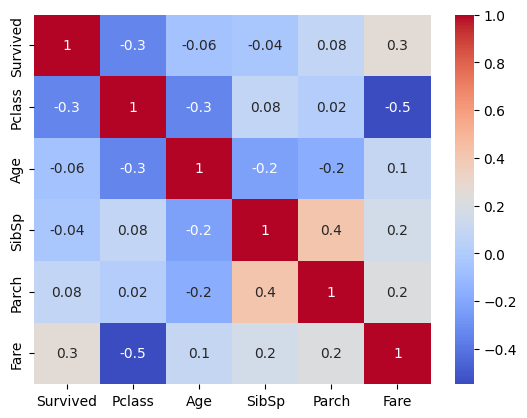

In [63]:
COR=titanic.corr(numeric_only=True)
sns.heatmap(COR, annot=True, cmap='coolwarm', fmt='.1g')

<Axes: xlabel='Survived', ylabel='count'>

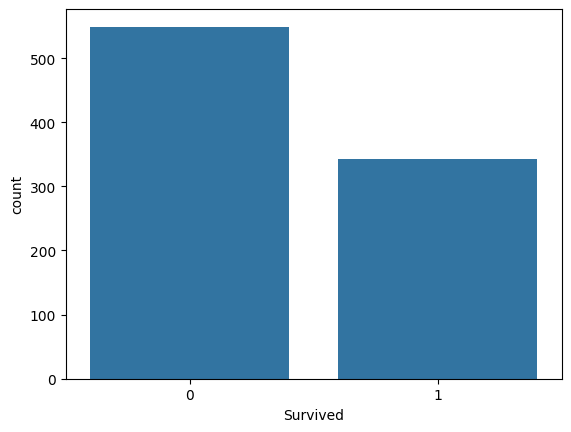

In [64]:
#countplot of the survived people
sns.countplot(x='Survived',  data=titanic)

<Axes: xlabel='Sex', ylabel='count'>

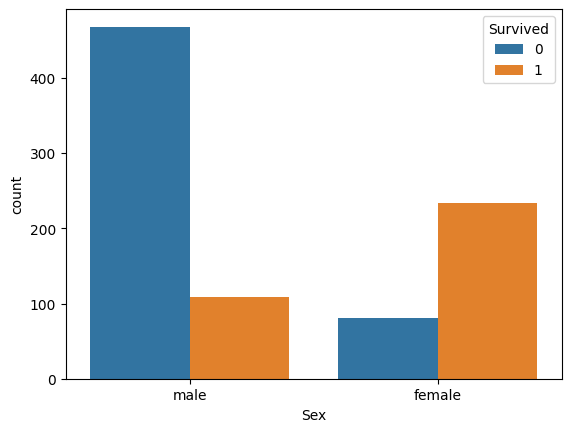

In [65]:
# count of the survival by gender
sns.countplot(x="Sex", hue="Survived", data=titanic)


<Axes: xlabel='Pclass', ylabel='count'>

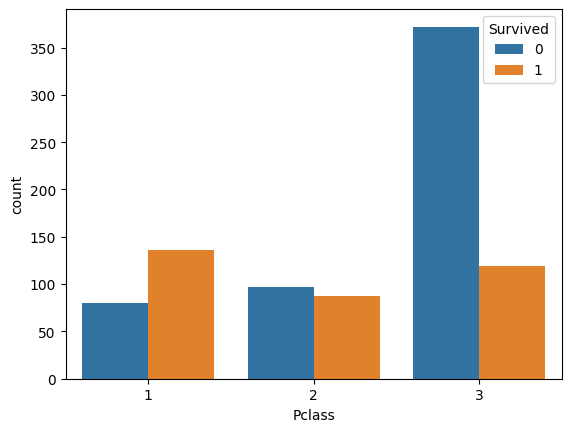

In [66]:
# survival according to the class
sns.countplot(x='Pclass', hue='Survived', data=titanic)

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [68]:
# converting sex to numeric
titanic['Sex']= titanic['Sex'].map({'male': 0, 'female': 1})

In [69]:
titanic = pd.get_dummies(titanic, columns=["Embarked"], drop_first=True).astype("int64")

In [70]:
# defining features and target

x=titanic.drop('Survived', axis=1)
y=titanic['Survived']

In [71]:
# splitting
x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.3, stratify=y, random_state=30)

In [72]:
model=Pipeline([
    ('scaler',StandardScaler()),
    ('smote',SMOTE(k_neighbors=3, random_state=42)),
    ('model',LogisticRegression(max_iter=1000))   
])
model.fit(x_train, y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,3
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'


In [73]:

y_pred=model.predict(x_test)
print(f'Accuracy:{accuracy_score(y_test,y_pred)}')
print(f'"\nConfussion matrix:\n" {confusion_matrix(y_test, y_pred)}')
print(f'"\nClassification report:\n" {classification_report(y_test, y_pred)}')

Accuracy:0.7835820895522388
"
Confussion matrix:
" [[131  34]
 [ 24  79]]
"
Classification report:
"               precision    recall  f1-score   support

           0       0.85      0.79      0.82       165
           1       0.70      0.77      0.73       103

    accuracy                           0.78       268
   macro avg       0.77      0.78      0.78       268
weighted avg       0.79      0.78      0.79       268



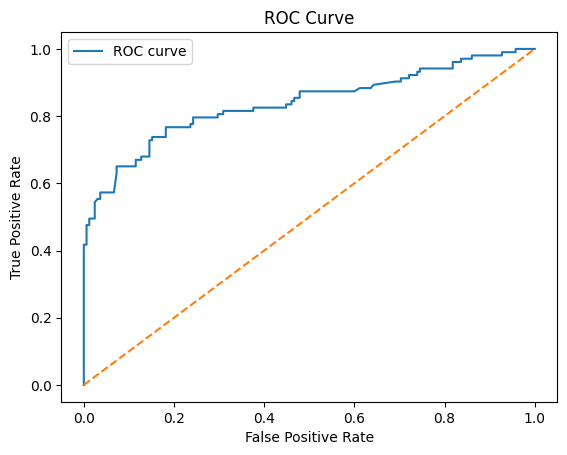

In [74]:
# Predict probabilities for the positive class (Survived = 1)
y_probs = model.predict_proba(x_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0, 1], [0, 1], linestyle="--")  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend();

In [75]:
roc_auc=roc_auc_score(y_test,y_probs)
print('ROC-AUC', roc_auc)

ROC-AUC 0.837834657252133


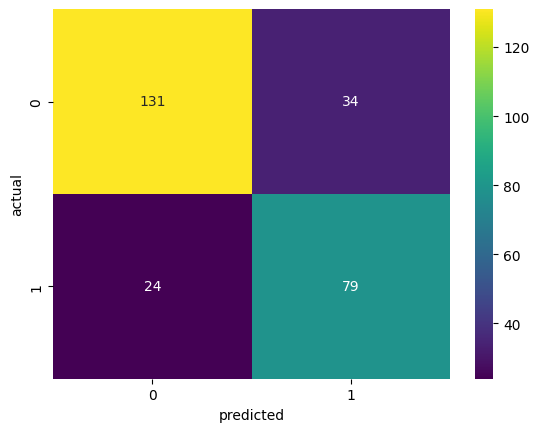

In [76]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True, fmt='d', cmap='viridis')
plt.xlabel('predicted')
plt.ylabel('actual');

In [77]:
# accessing coefficient & intercept using pipeline
intercept= model.named_steps['model'].intercept_
coefficients = model.named_steps['model'].coef_
print('intercept', intercept)
print('coefficients', coefficients)

intercept [-0.19826607]
coefficients [[-1.01127419  1.2751865  -0.44423476 -0.28276377  0.01536812  0.07407619
  -0.02402912 -0.09446639]]


In [78]:
features_names = x.columns

In [79]:
coefficients = model.named_steps['model'].coef_[0]

feature_importance = pd.DataFrame({
    'Feature': features_names,
    'coefficients': coefficients
}).sort_values(by='coefficients', ascending=False)

print(feature_importance)

      Feature  coefficients
1         Sex      1.275186
5        Fare      0.074076
4       Parch      0.015368
6  Embarked_Q     -0.024029
7  Embarked_S     -0.094466
3       SibSp     -0.282764
2         Age     -0.444235
0      Pclass     -1.011274


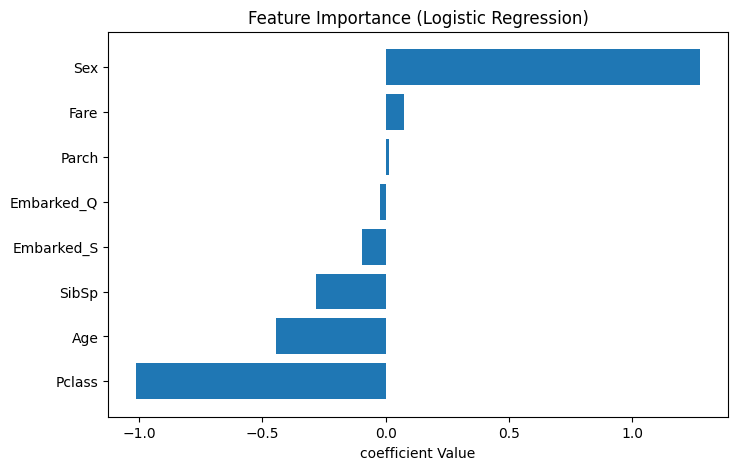

In [80]:
plt.figure(figsize=(8,5))
plt.barh(feature_importance["Feature"], feature_importance["coefficients"])
plt.xlabel("coefficient Value")
plt.title("Feature Importance (Logistic Regression)")
plt.gca().invert_yaxis()
plt.show()